In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


In [2]:
dataset_path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
print('Dataset folder:', dataset_path)

csv_files = glob.glob(os.path.join(dataset_path, '**', '*.csv'), recursive=True)
if not csv_files:
    raise FileNotFoundError('No CSV file found.')

csv_path = next((p for p in csv_files if os.path.basename(p).lower() == 'creditcard.csv'), csv_files[0])
df = pd.read_csv(csv_path)

print('Loaded file:', csv_path)
print('Dataset shape:', df.shape)
display(df.head())


Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset folder: /kaggle/input/creditcardfraud
Loaded file: /kaggle/input/creditcardfraud/creditcard.csv
Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64

Percentages:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


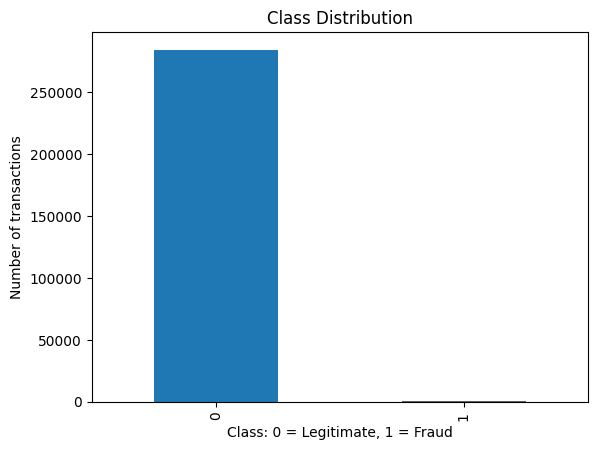

In [3]:
print(df['Class'].value_counts())
print('\nPercentages:')
print((df['Class'].value_counts(normalize=True) * 100).round(4))

df['Class'].value_counts().plot(kind='bar', title='Class Distribution')
plt.xlabel('Class: 0 = Legitimate, 1 = Fraud')
plt.ylabel('Number of transactions')
plt.show()


In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)


Training shape: (227845, 30)
Testing shape: (56962, 30)


In [5]:
print('Before SMOTE:')
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(pd.Series(y_train_resampled).value_counts())


Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [6]:
model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train_resampled, y_train_resampled)
print('XGBoost training completed.')


XGBoost training completed.


In [7]:
y_prob = model.predict_proba(X_test)[:, 1]
results = pd.DataFrame({'actual_class': y_test.values, 'fraud_probability': y_prob})
display(results.head(10))


,actual_class,fraud_probability
0,0,0.004570
1,0,0.004124
2,0,0.040133
3,0,0.001905
4,0,0.090658
5,0,0.008282
6,0,0.002954
7,0,0.002729
8,0,0.008880
9,0,0.004308


In [8]:
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print(f'PR-AUC:  {average_precision_score(y_test, y_prob):.4f}')


ROC-AUC: 0.9776
PR-AUC:  0.8206


In [9]:
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    threshold_results.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_threshold, zero_division=0),
        'recall': recall_score(y_test, y_pred_threshold, zero_division=0),
        'f1_score': f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df.round(4))


,threshold,precision,recall,f1_score
0,0.1,0.0344,0.9286,0.0664
1,0.2,0.0670,0.9184,0.1249
2,0.3,0.1032,0.9082,0.1854
3,0.4,0.1486,0.8980,0.2551
4,0.5,0.2080,0.8980,0.3378
5,0.6,0.2890,0.8878,0.4361
6,0.7,0.3857,0.8776,0.5358


In [10]:
chosen_threshold = 0.30
y_pred = (y_prob >= chosen_threshold).astype(int)

print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification report:')
print(classification_report(y_test, y_pred, zero_division=0))


Confusion matrix:
[[56091   773]
 [    9    89]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.10      0.91      0.19        98

    accuracy                           0.99     56962
   macro avg       0.55      0.95      0.59     56962
weighted avg       1.00      0.99      0.99     56962



,feature,importance
14,V14,0.491178
10,V10,0.128316
17,V17,0.044707
4,V4,0.042060
12,V12,0.031782
8,V8,0.025122
3,V3,0.020612
13,V13,0.016195
1,V1,0.014756
5,V5,0.013260


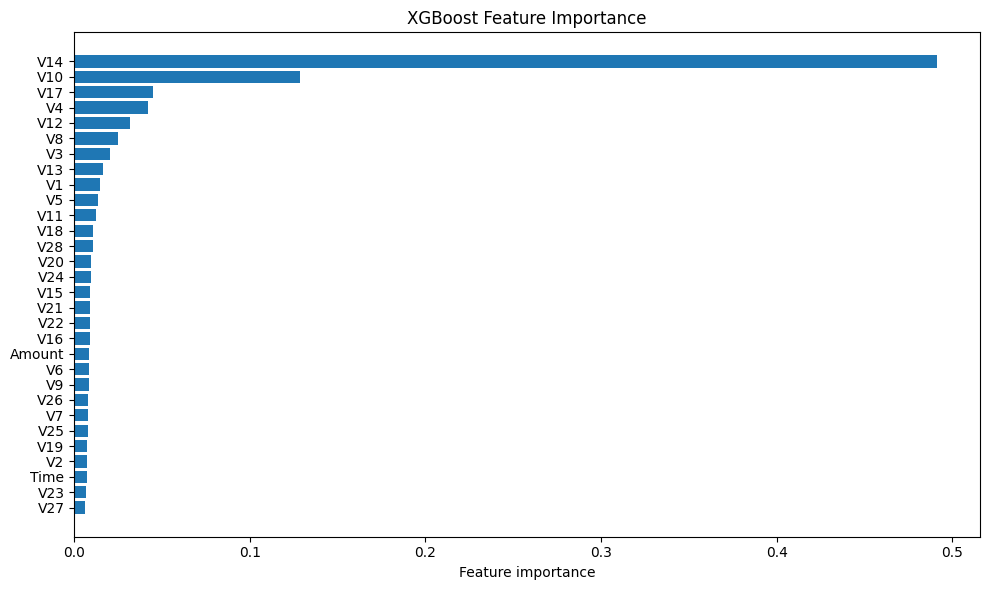

In [11]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.xlabel('Feature importance')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()
